In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#installing libraries
!pip install datasets

In [ ]:
## From lab 7
## This code here just makes it so you don't need an API
## key for Weights and Biases. Just run it, and you're good.

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from datasets import load_dataset

csv_file_path = '/content/drive/MyDrive/NLPData/dancing1000v2.csv'

#load the dataset from the local CSV file
dancing_dataset = load_dataset('csv', data_files=csv_file_path)

#display the first few examples of the dataset
print(dancing_dataset)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres'],
        num_rows: 1000
    })
})


In [ ]:
#create a randomized 80/20 train-test split
train_test_dataset = dancing_dataset['train'].train_test_split(test_size=0.2, seed=42)

print(train_test_dataset)

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres'],
        num_rows: 800
    })
    test: Dataset({
        features: ['Unnamed: 0', 'id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres'],
        num_rows: 200
    })
})


In [ ]:
#function to create labels based on danceability score
def create_danceability_labels(example):
    danceability = example['danceability']
    if danceability < 0.4:
        example['labels'] = 0 # 'low danceability'
    elif danceability > 0.6:
        example['labels'] = 1 # 'high danceability'
    else:
        example['labels'] = -1 # Mark for removal or as 'intermediate'
    return example

#apply the labeling function to both train and test splits
train_test_dataset_labeled = train_test_dataset.map(create_danceability_labels)

#filter out examples that are not 'low danceability' or 'high danceability'
train_test_dataset_filtered = train_test_dataset_labeled.filter(lambda example: example['labels'] != -1)

#update the 'train' and 'test' splits with the filtered data
train_dataset = train_test_dataset_filtered['train']
test_dataset = train_test_dataset_filtered['test']

#display the updated datasets to show the new 'labels' column and filtered counts
print("Filtered Training Data:", train_dataset)
print("Filtered Test Data:", test_dataset)

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/200 [00:00<?, ? examples/s]

Filtered Training Data: Dataset({
    features: ['Unnamed: 0', 'id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'labels'],
    num_rows: 800
})
Filtered Test Data: Dataset({
    features: ['Unnamed: 0', 'id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'labels'],
    num_rows: 200
})


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 107.2 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Extract tokenized words from the training dataset
# The tokenizer function usually returns 'input_ids', which are integer representations of tokens.
# We need to convert these back to words or use the original words if available.
# Assuming `tokenize_function` provides `input_ids`, we'll need to decode them or re-tokenize for Word2Vec.
# For simplicity, let's re-tokenize the raw lyrics into words for Word2Vec training.

# First, get the raw lyrics from the filtered training dataset
raw_train_lyrics = [str(lyric).lower().split() for lyric in train_dataset["lyrics"] if lyric is not None]

# Train Word2Vec model
# Using skip-gram (sg=1), window size of 5, min_count to ignore infrequent words, and 100 dimensions for embeddings
word2vec_model = Word2Vec(sentences=raw_train_lyrics, vector_size=100, window=5, min_count=1, workers=4, sg=1)

print("Word2Vec model training complete.")
print(f"Vocabulary size: {len(word2vec_model.wv)}")

Word2Vec model training complete.
Vocabulary size: 17906


In [ ]:
#function to get averaged Word2Vec vector for a document (song lyrics)

import numpy as np

def get_word2vec_embedding(lyrics_tokens, model, vector_size):
    embeddings = []
    for token in lyrics_tokens:
        if token in model.wv:
            embeddings.append(model.wv[token])
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(vector_size)

#create Word2Vec embeddings for train and test datasets
X_train_w2v = np.array([get_word2vec_embedding(str(lyric).lower().split(), word2vec_model, 100)
                        for lyric in train_dataset["lyrics"]])
X_test_w2v = np.array([get_word2vec_embedding(str(lyric).lower().split(), word2vec_model, 100)
                       for lyric in test_dataset["lyrics"]])

y_train = np.array(train_dataset["labels"])
y_test = np.array(test_dataset["labels"])

print(f"Shape of Word2Vec training embeddings: {X_train_w2v.shape}")
print(f"Shape of Word2Vec test embeddings: {X_test_w2v.shape}")

Shape of Word2Vec training embeddings: (800, 100)
Shape of Word2Vec test embeddings: (200, 100)


KNN + Random Forest

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_w2v, y_train)
knn_preds = knn.predict(X_test_w2v)
print("KNN:")
print(classification_report(y_test, knn_preds))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_w2v, y_train)
rf_preds = rf.predict(X_test_w2v)
print("Random Forest:")
print(classification_report(y_test, rf_preds))

KNN:
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       104
           1       0.63      0.65      0.64        96

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.65      0.65       200

Random Forest:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       104
           1       0.72      0.67      0.69        96

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



/tmp/ipykernel_4528/808518883.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df.groupby('danceability_bin').apply(
/tmp/ipykernel_4528/808518883.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = df.groupby('danceability_bin').apply(
/tmp/ipykernel_4528/808518883.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

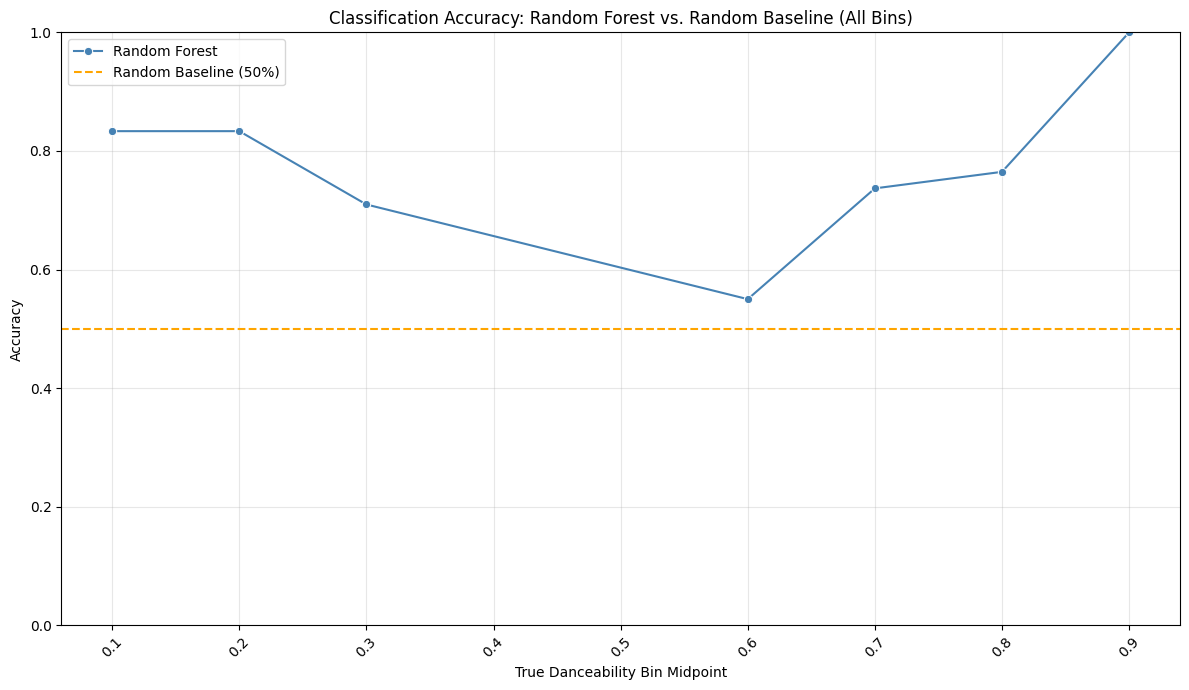

/tmp/ipykernel_4528/808518883.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df.groupby('danceability_bin').apply(
/tmp/ipykernel_4528/808518883.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = df.groupby('danceability_bin').apply(


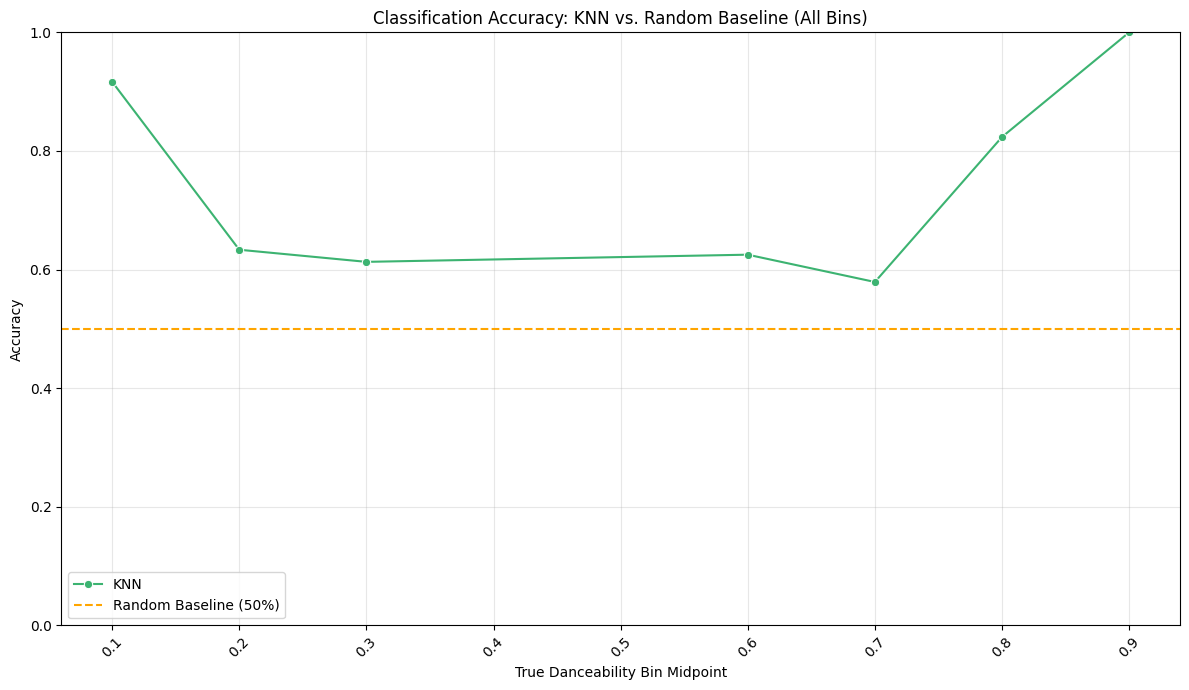

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

test_danceability_scores = np.array(test_dataset['danceability'])
bins = np.arange(0, 1.1, 0.1)
labels = [f'{i:.1f}' for i in np.arange(0, 1, 0.1)]

def get_binned_accuracy(y_true, y_pred, danceability):
    df = pd.DataFrame({
        'danceability': danceability,
        'true_label': y_true,
        'predicted_label': y_pred
    })
    df['danceability_bin'] = pd.cut(df['danceability'], bins=bins, labels=labels, right=False)
    binned = df.groupby('danceability_bin').apply(
        lambda x: accuracy_score(x['true_label'], x['predicted_label']) if len(x) > 0 else np.nan
    ).reset_index(name='accuracy')
    return binned.dropna()

rf_binned  = get_binned_accuracy(y_test, rf_preds,  test_danceability_scores)
knn_binned = get_binned_accuracy(y_test, knn_preds, test_danceability_scores)

for preds, title, color in [
    (rf_preds,  'Random Forest', 'steelblue'),
    (knn_preds, 'KNN',           'mediumseagreen'),
]:
    binned = get_binned_accuracy(y_test, preds, test_danceability_scores)

    plt.figure(figsize=(12, 7))
    sns.lineplot(x='danceability_bin', y='accuracy', data=binned,
                 marker='o', color=color, label=title)
    plt.axhline(0.5, color='orange', linestyle='--', label='Random Baseline (50%)')
    plt.title(f'Classification Accuracy: {title} vs. Random Baseline (All Bins)')
    plt.xlabel('True Danceability Bin Midpoint')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'binned_accuracy_{title.lower().replace(" ", "_")}.png')
    plt.show()